In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statannotations.Annotator import Annotator
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

In [2]:
mutcat_path = "data/positions_mutcat.tsv"
roles_path = "data/generoles.tsv"

In [3]:
mutcat = pd.read_csv(mutcat_path, sep='\t')
roles = pd.read_csv(roles_path, sep = '\t')

In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

To obtain protein domain coordinates: https://www.uniprot.org/uniprotkb/P04637/entry
<br>Search protein name, select correct gene in correct species
<br>Navigate to 'View protein in Pfam' (if no Pfam, 'View protein in Interpro')

---

In [7]:
# preparing dataset

mutcat_tmp = mutcat.copy()
mutcat_tmp['SampleID'] = mutcat_tmp['gene_patient']+'_'+mutcat_tmp['zygosity_genepatient']

mutcat_mod = mutcat[~mutcat.Protein_position.isin(['.','?','nan'])].dropna()
mutcat_mod['Protein_position'] = mutcat_mod['Protein_position'].astype('int64')

print(len(mutcat))
print(len(mutcat_mod))

tsgs = roles[roles.role=='TSG']['Hugo_Symbol'].unique()

tmp = mutcat_mod[mutcat_mod.Hugo_Symbol.isin(tsgs)]
tmp = tmp.groupby(['Hugo_Symbol','zygosity_genepatient','Mutation_Category_genepatient'])['Protein_position'].value_counts().to_frame().rename(columns={'Protein_position':'Count'}).reset_index()
tmp1 = tmp[tmp.zygosity_genepatient=='1-hit'].copy()
tmp2 = tmp[tmp.zygosity_genepatient=='2-hit'].copy()
tmp2['Count'] = tmp2['Count'].apply(lambda x:x*(-1))
tmp = pd.concat([tmp1,tmp2])
lolli = tmp.copy()
lolli.columns = ['gene','zygosity','mutcat','position','count']

771573
771573


In [8]:
# defining plotting function

def plot_lollipop_with_domains(
    gene,
    data,
    domain_info,
    protein_length=None,
    figsize=(6, 4),
    yticks_top=None,
    yticks_bottom=None,
    hspace=0,
    track_height=4,
    heightratio=10,
    extraytoplim=0,
    extraybotlim=0,
    toppad=10,
    bottompad=10,
    top_label_y=None,
    bottom_label_y=None,
    xpad=5,  
):
    # Filter for gene
    data_gene = data[data.gene == gene].reset_index(drop=True)
    
    if protein_length is None:
        protein_length = data_gene['position'].max()
    
    # Separate top and bottom stems
    data_toplof = data_gene[(data_gene.mutcat=='lof') & (data_gene['count']>0)]
    data_topmis = data_gene[(data_gene.mutcat=='mis') & (data_gene['count']>0)]
    data_botlof = data_gene[(data_gene.mutcat=='lof') & (data_gene['count']<0)]
    data_botmis = data_gene[(data_gene.mutcat=='mis') & (data_gene['count']<0)]
    
    config_rcparams()
    
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(
        3, 1,
        height_ratios=[
            data_gene['count'].max() + extraytoplim,
            heightratio,
            abs(data_gene['count'].min()) + extraybotlim
        ],
        hspace=hspace
    )
    
    ax_top = fig.add_subplot(gs[0])
    ax_domain = fig.add_subplot(gs[1], sharex=ax_top)
    ax_bottom = fig.add_subplot(gs[2], sharex=ax_top)
    
    # --- Top stems
    markerline1, stemlines1, baseline1 = ax_top.stem(
        data_toplof['position'], data_toplof['count'],
        linefmt='k-', markerfmt='o', basefmt=" "
    )
    plt.setp(stemlines1, color='black', alpha=0.7, linewidth=0.8)
    plt.setp(markerline1, color='#8976E3', markersize=4, alpha=0.6)

    markerline2, stemlines2, baseline2 = ax_top.stem(
        data_topmis['position'], data_topmis['count'],
        linefmt='k-', markerfmt='o', basefmt=" "
    )
    plt.setp(stemlines2, color='black', alpha=0.7, linewidth=0.8)
    plt.setp(markerline2, color='#f1a340', markersize=4, alpha=0.6)
    
    # --- Bottom stems
    markerline3, stemlines3, baseline3 = ax_bottom.stem(
        data_botlof['position'], data_botlof['count'],
        linefmt='k-', markerfmt='o', basefmt=" "
    )
    plt.setp(stemlines3, color='black', alpha=0.7, linewidth=0.8)
    plt.setp(markerline3, color='#8976E3', markersize=4, alpha=0.6)

    markerline4, stemlines4, baseline4 = ax_bottom.stem(
        data_botmis['position'], data_botmis['count'],
        linefmt='k-', markerfmt='o', basefmt=" "
    )
    plt.setp(stemlines4, color='black', alpha=0.7, linewidth=0.8)
    plt.setp(markerline4, color='#f1a340', markersize=4, alpha=0.6)
    
    # --- Formatting stems
    ax_top.spines['bottom'].set_visible(False)
    ax_bottom.spines['top'].set_visible(False)
    ax_top.tick_params(axis='x', bottom=False, labelbottom=False)

    ax_top.set_ylim(0, data_gene['count'].max() + toppad)
    ax_bottom.set_ylim(data_gene['count'].min() - bottompad, 0)

    ax_top.set_yticks(yticks_top)
    ax_top.set_yticklabels([str(y) for y in yticks_top])

    ax_bottom.set_yticks(yticks_bottom)
    ax_bottom.set_yticklabels([str(abs(y)) for y in yticks_bottom])  

    for spine in ["top", "right"]:
        ax_top.spines[spine].set_visible(False)
        ax_bottom.spines[spine].set_visible(False)
    
    # --- Top/Bottom labels
    if top_label_y is not None:
        ax_top.text(
            0.01, top_label_y,
            "One-hit",
            transform=ax_top.transAxes,  # x in fraction, y in axis scale
            ha="left", va="center",
            fontsize=11, fontweight="bold"
        )
    if bottom_label_y is not None:
        ax_bottom.text(
            0.01, bottom_label_y,
            "Two-hit",
            transform=ax_bottom.transAxes,
            ha="left", va="center",
            fontsize=11, fontweight="bold"
        )
    
    # --- Domains
    domain_info = sorted(domain_info, key=lambda x: x[0])
    track_bottom = -track_height / 2

    ax_domain.add_patch(
        patches.Rectangle(
            (1, track_bottom), protein_length-1, track_height,
            facecolor="lightgray", edgecolor="none", alpha=0.9, zorder=1
        )
    )

    for (start, end, label, color) in domain_info:
        ax_domain.add_patch(
            patches.Rectangle(
                (start, track_bottom), end-start, track_height,
                facecolor=color, edgecolor="none", alpha=0.95, zorder=3
            )
        )
        ax_domain.text(
            (start+end)/2, 0, label,
            ha="center", va="center", fontsize=8, color="black", zorder=4
        )

    # --- X limits (apply padding on left)
    ax_domain.set_xlim(-xpad, protein_length+5)
    ax_domain.set_ylim(-2, 2)
    ax_domain.set_yticks([])
    #ax_top.set_xticks([])
    for spine in ax_domain.spines.values():
        spine.set_visible(False)
    ax_domain.set_ylabel("") 
    
    fig.suptitle(gene, fontsize=14, y=0.95)
    fig.text(0.03, 0.5, "# Point Mutation", va='center', rotation='vertical', fontsize=12)
    plt.show()


---

# Fig 2E

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


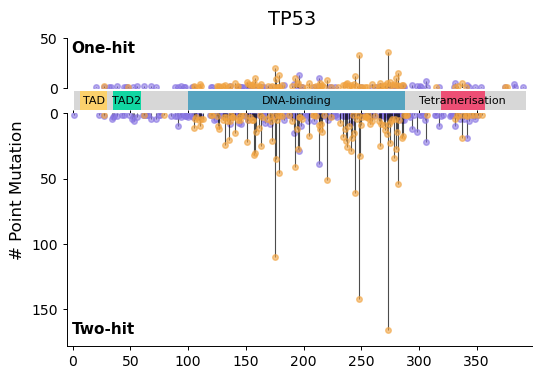

In [9]:
plot_lollipop_with_domains(
    gene="TP53",
    data=lolli,
    domain_info=[
        (6, 30, "TAD", "#FFD166"),
        (35, 59, "TAD2", "#06D6A0"),
        (100, 288, "DNA-binding", "#50A2BF"),
        (319, 357, "Tetramerisation", "#EF476F"),
    ],
    protein_length=393,
    yticks_top=[0, 50],
    yticks_bottom=[0, -50, -100, -150],
    hspace=0.03,
    track_height=6,
    heightratio = 13.5,
    toppad = 12,
    bottompad = 12,
    top_label_y=0.8,
    bottom_label_y=0.07,
    xpad=5
)


---

# Fig 2F

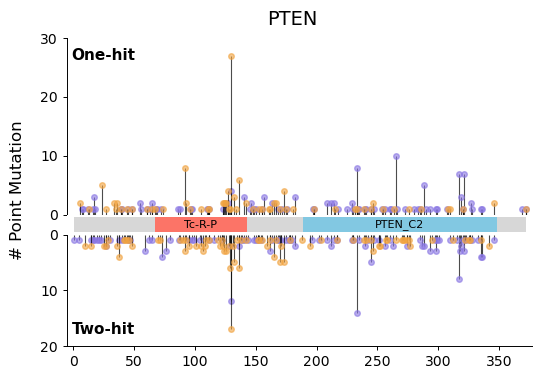

In [10]:
plot_lollipop_with_domains(
    gene="PTEN",
    data=lolli,
    domain_info=[
        (67, 143, "Tc-R-P", "#FF6F61"),
        (189, 348, "PTEN_C2", "#7EC8E3"),
    ],
    yticks_top=[0, 10, 20, 30],
    yticks_bottom=[0, -10, -20],
    hspace=0,
    track_height=3,
    heightratio = 3,
    toppad = 2,
    bottompad = 2,
    top_label_y=0.9,
    bottom_label_y=0.15,
    xpad=5
)

---

# Fig 2G

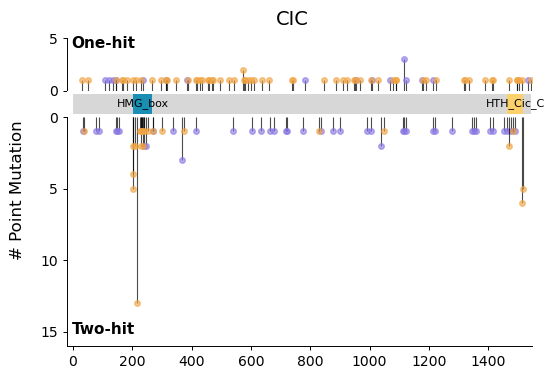

In [11]:
plot_lollipop_with_domains(
    gene="CIC",
    data=lolli,
    domain_info=[
        (201, 268, "HMG_box", "#118AB2"), #"DUF4819"
        (1463, 1517, "HTH_Cic_C", "#FFD166"),
    ],
    yticks_top=[0, 5],
    yticks_bottom=[0, -5, -10, -15],
    hspace=0,
    track_height=3,
    heightratio = 1.5,
    toppad =1,
    bottompad = 3,
    top_label_y=0.9,
    bottom_label_y=0.07,
    xpad=20
)

---

# Fig S4

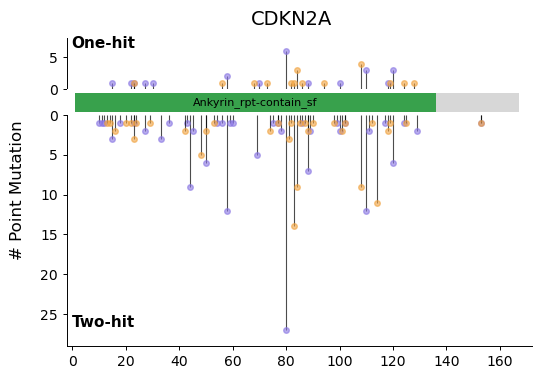

In [12]:
plot_lollipop_with_domains(
    gene="CDKN2A",
    data=lolli,
    domain_info=[
        (1, 136, "Ankyrin_rpt-contain_sf", "#2F9E44"),
    ],
    yticks_top=[0, 5],
    yticks_bottom=[0, -5, -10, -15, -20, -25],
    hspace=0,
    track_height=3,
    heightratio = 3,
    toppad = 2,
    bottompad = 2,
    top_label_y=0.9,
    bottom_label_y=0.1,
    xpad=2
)

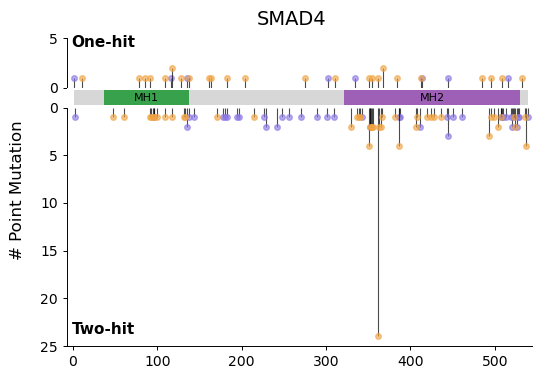

In [13]:
plot_lollipop_with_domains(
    gene="SMAD4",
    data=lolli,
    domain_info=[
        (37, 137, "MH1", "#2F9E44"),
        (321, 530, "MH2", "#9B59B6"),
    ],
    yticks_top=[0, 5],
    yticks_bottom=[0, -5, -10, -15, -20, -25],
    hspace=0,
    track_height=3,
    heightratio = 2,
    toppad = 0,
    bottompad = 0,
    top_label_y=0.9,
    bottom_label_y=0.07,
    extraytoplim = 3,
    xpad=7
)

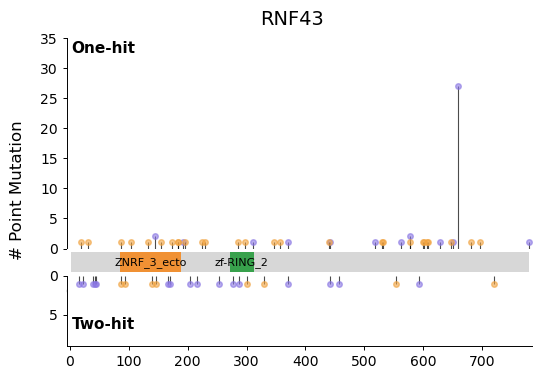

In [14]:
plot_lollipop_with_domains(
    gene="RNF43",
    data=lolli,
    domain_info=[
        (85, 189, "ZNRF_3_ecto", "#F28E2B"),
        (272, 312, "zf-RING_2", "#2F9E44")
    ],
    yticks_top=[0, 5, 10, 15, 20, 25, 30, 35],
    yticks_bottom=[0, -5],
    hspace=0,
    track_height=3,
    heightratio = 3.5,
    toppad =1,
    bottompad = 8,
    top_label_y=0.95,
    bottom_label_y=0.3,
    extraybotlim = 8,
    xpad=5
)

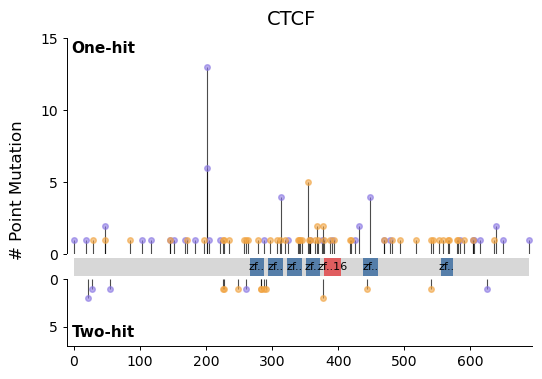

In [15]:
plot_lollipop_with_domains(
    gene="CTCF",
    data=lolli,
    domain_info=[
        (266, 288, "zf..", "#4E79A7"),
        (294, 316, "zf..", "#4E79A7"),
        (322, 345, "zf..", "#4E79A7"),
        (351, 373, "zf..", "#4E79A7"),
        (437, 460, "zf..", "#4E79A7"),
        (555, 573, "zf..", "#4E79A7"),
        (379, 404, "zf..16", "#E15759"),
    ],
    yticks_top=[0, 5, 10, 15],
    yticks_bottom=[0, -5],
    hspace=0,
    track_height=3,
    heightratio = 1.5,
    toppad = 2,
    bottompad = 5,
    top_label_y=0.95,
    bottom_label_y=0.2,
    extraybotlim = 2,
    xpad=10
)

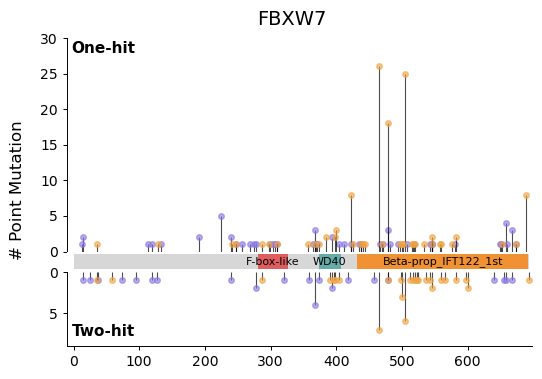

In [16]:
plot_lollipop_with_domains(
    gene="FBXW7",
    data=lolli,
    domain_info=[
        (281, 326, "F-box-like", "#E15759"),
        (373, 407, "WD40", "#5EAAA8"),
        (432, 692, "Beta-prop_IFT122_1st", "#F28E2B"),
        
    ],
    yticks_top=[0, 5, 10, 15, 20, 25, 30],
    yticks_bottom=[0, -5],
    hspace=0,
    track_height=3,
    heightratio = 2.5,
    toppad =2,
    bottompad = 2,
    top_label_y=0.95,
    bottom_label_y=0.2,
    extraybotlim = 2,
    xpad=10
)

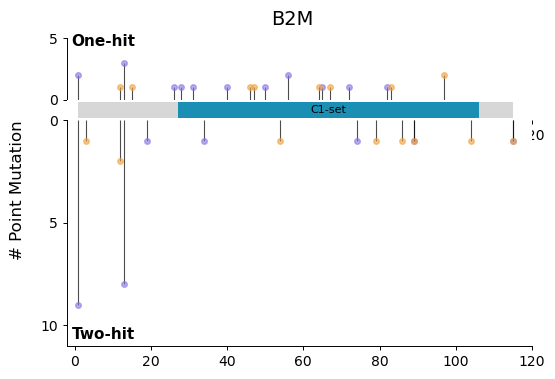

In [17]:
plot_lollipop_with_domains(
    gene="B2M",
    data=lolli,
    domain_info=[
        (27, 106, "C1-set", "#118AB2"),
        
    ],
    yticks_top=[0, 5],
    yticks_bottom=[0, -5, -10],
    hspace=0,
    track_height=3,
    heightratio = 1,
    toppad =2,
    bottompad = 2,
    top_label_y=0.95,
    bottom_label_y=0.05,
    extraybotlim = 2,
    xpad=2
)

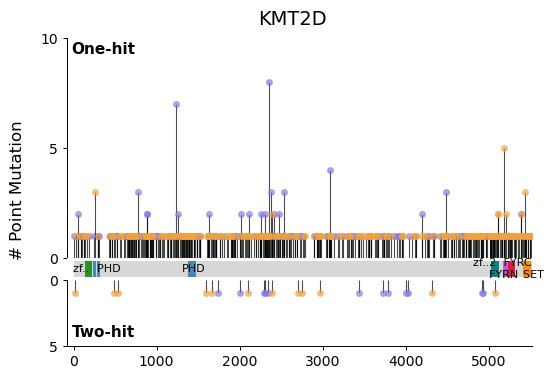

In [18]:
plot_lollipop_with_domains(
    gene="KMT2D",
    data=lolli,
    domain_info=[
        (229, 273, "", "#4682B4"),
        (276, 320, "      PHD", "#4682B4"),
        (1380, 1427, "", "#4682B4"),
        (1430, 1474, "PHD", "#4682B4"),
        (139, 218, "zf..    ", "#228B22"),
        (5408, 5513, "\n    SET", "#FF8C00"),
        (5177, 5234, "\nFYRN ", "#BA55D3"),
        (5238, 5322, "   FYRC\n", "#DC143C"),
        (5031, 5129, "zf..2      \n", "#008080"),
        
    ],
    yticks_top=[0, 5, 10],
    yticks_bottom=[0, -5],
    hspace=0,
    track_height=3,
    heightratio = 1,
    toppad =1,
    bottompad = 1,
    top_label_y=0.95,
    bottom_label_y=0.2,
    extraybotlim = 2,
    extraytoplim = 2,
    xpad=80
)

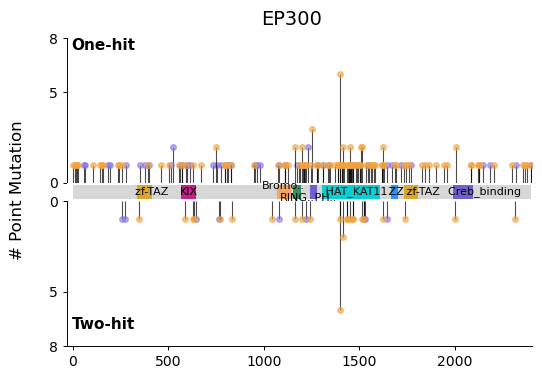

In [19]:
plot_lollipop_with_domains(
    gene="EP300",
    data=lolli,
    domain_info=[
        (1068, 1143, "Bromo..\n", "#F4A460"),
        (1665, 1705, " ZZ", "#1E90FF"),
        (338, 414, "    zf-TAZ", "#DAA520"),
        (1735, 1806, "       zf-TAZ", "#DAA520"),
        (567, 646, "KIX", "#C71585"),
        (1156, 1195, "\nRING..", "#2E8B57"),
        (1306, 1611, "   HAT_KAT11", "#00CED1"),
        (1992, 2098, "            Creb_binding", "#6A5ACD"),
        (1240, 1278, "\n       PH..", "#6A5ACD"),
    ],
    yticks_top=[0, 5, 8],
    yticks_bottom=[0, -5, -8],
    hspace=0,
    track_height=3,
    heightratio = 1,
    toppad =1,
    bottompad = 1,
    top_label_y=0.95,
    bottom_label_y=0.15,
    extraybotlim = 2,
    extraytoplim = 2,
    xpad=30
)

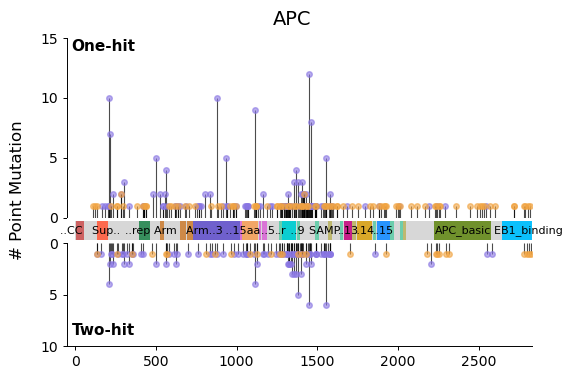

In [20]:
plot_lollipop_with_domains(
    gene="APC",
    data=lolli,
    domain_info=[
        (523, 552, "  Arm", "#CD853F"),
        (649, 689, "", "#CD853F"),
        (691, 730, "", "#CD853F"),
        (1260, 1280, "..r", "#66CDAA"),
        (1372, 1393, "", "#66CDAA"),
        (1486, 1509, "", "#66CDAA"),
        (1637, 1660, "", "#66CDAA"),
        (1841, 1865, "", "#66CDAA"),
        (1950, 1972, "", "#66CDAA"),
        (2008, 2030, "", "#66CDAA"),
        (1567, 1588, "SAMP   ", "#BDB76B"),
        (1717, 1737, "", "#BDB76B"),
        (2031, 2051, "", "#BDB76B"),
        (2640, 2843, "      EB1_binding", "#00BFFF"),
        (2224, 2575, "APC_basic", "#6B8E23"),
        (1020, 1034, " ..15aa", "#DA70D6"),
        (1136, 1150, "", "#DA70D6"),
        (1155, 1169, "", "#DA70D6"),
        (1172, 1186, "", "#DA70D6"),
        (134, 202, "  Sup..", "#FF6347"),
        (732, 1019, "Arm..3       ", "#6A5ACD"),
        (1036, 1135, "          ..5", "#F4A460"),
        (1282, 1368, "     ..9", "#00CED1"),
        (1662, 1717, "..13", "#C71585"),
        (1746, 1839, "..14", "#DAA520"),
        (1867, 1947, "..15", "#1E90FF"),
        (4, 55, "..CC     ", "#CD5C5C"),
        (393, 466, "..rep    ", "#2E8B57"),
    ],
    yticks_top=[0, 5, 10, 15],
    yticks_bottom=[0, -5, -10],
    hspace=0,
    track_height=3,
    heightratio = 2,
    toppad =1,
    bottompad = 1,
    top_label_y=0.95,
    bottom_label_y=0.15,
    extraybotlim = 2,
    extraytoplim = 2,
    xpad=50
    
)

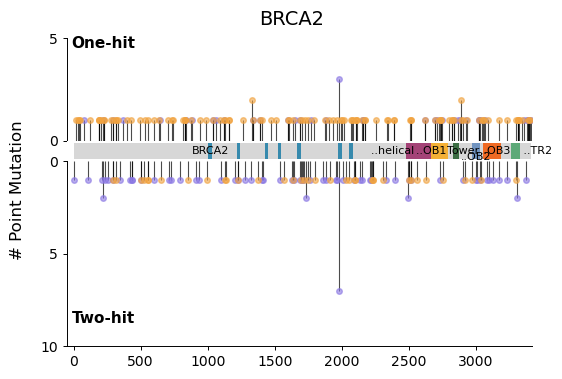

In [21]:
plot_lollipop_with_domains(
    gene="BRCA2",
    data=lolli,
    domain_info=[
        (1005, 1033, "BRCA2", "#2E86AB"),
        (1216, 1243, "", "#2E86AB"),
        (1424, 1452, "", "#2E86AB"),
        (1522, 1548, "", "#2E86AB"),
        (1667, 1695, "", "#2E86AB"),
        (1975, 2002, "", "#2E86AB"),
        (2055, 2082, "", "#2E86AB"),
        (2670, 2795, "..OB1     ", "#F6AE2D"),
        (3052, 3185, "  ..OB3", "#F26419"),
        (2831, 2872, "    Tower", "#33673B"),
        (2482, 2667, "..helical               ", "#A23B72"),
        (2969, 3035, "\n..OB2", "#6C91BF"),
        (3260, 3334, "             ..TR2", "#57A773"),
    ],
    yticks_top=[0, 5],
    yticks_bottom=[0, -5, -10],
    hspace=0,
    track_height=3,
    heightratio = 1,
    toppad =1,
    bottompad = 1,
    top_label_y=0.95,
    bottom_label_y=0.15,
    extraybotlim = 2,
    extraytoplim = 2,
    xpad=50
)

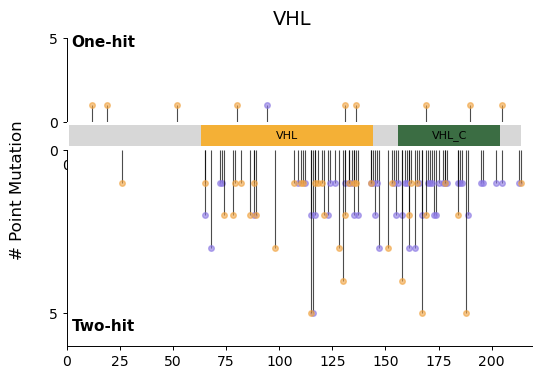

In [22]:
plot_lollipop_with_domains(
    gene="VHL",
    data=lolli,
    domain_info=[
        (63, 144, "VHL", "#F6AE2D"),
        (156, 204, "VHL_C", "#33673B"),
    ],
    yticks_top=[0, 5],
    yticks_bottom=[0, -5],
    hspace=0,
    track_height=3,
    heightratio = 1,
    toppad =1,
    bottompad = 1,
    top_label_y=0.95,
    bottom_label_y=0.1,
    extraybotlim = 2,
    extraytoplim = 2,
    xpad=0
)

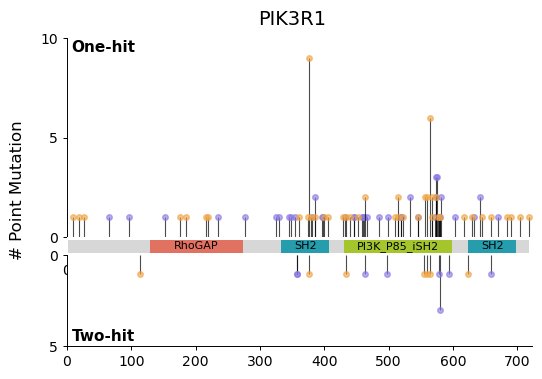

In [23]:
plot_lollipop_with_domains(
    gene="PIK3R1",
    data=lolli,
    domain_info=[
        (333, 408, "SH2", "#1B9AAA"),
        (624, 698, "SH2", "#1B9AAA"),
        (129, 274, "RhoGAP", "#E26D5C"),
        (431, 599, "PI3K_P85_iSH2", "#A2C523"),
    ],
    yticks_top=[0, 5, 10],
    yticks_bottom=[0, -5],
    hspace=0,
    track_height=3,
    heightratio = 1,
    toppad =1,
    bottompad = 1,
    top_label_y=0.95,
    bottom_label_y=0.1,
    extraybotlim = 2,
    extraytoplim = 2,
    xpad=0
)

---